In [11]:
# 📦 Schritt 1: Bibliotheken importieren
import pandas as pd
import glob
import os

# 📁 Schritt 2: Pfad zu den Metrics-Dateien definieren
folder_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA/"
file_pattern = os.path.join(folder_path, "Metrics_*.csv")

# 📂 Schritt 3: Alle passenden CSV-Dateien finden
file_list = glob.glob(file_pattern)
print(f"{len(file_list)} Dateien gefunden.")

# 📊 Schritt 4: Alle Dateien einlesen und zusammenfügen
all_dfs = [pd.read_csv(file) for file in file_list]
full_df = pd.concat(all_dfs, ignore_index=True)
print("Daten erfolgreich zusammengeführt.")
display(full_df.head())

# 📈 Schritt 5: Durchschnittswerte pro Instanz + Algorithmus berechnen
average_df = full_df.groupby(["Instance", "Algorithm"], as_index=False).mean()
print("Durchschnittswerte berechnet.")
display(average_df.head())

# 💾 Schritt 6: Ergebnis abspeichern
output_path = os.path.join(folder_path, "Metrics_averaged.csv")
average_df.to_csv(output_path, index=False)
print(f"Aggregierte Datei gespeichert unter: {output_path}")

11 Dateien gefunden.
Daten erfolgreich zusammengeführt.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a3_o80_m10_an10_ar9_reduced,PSA,256.75,0.384848,0.820218,0.637449,0.071815,20.588235,0.212044,0.553650
1,a3_o80_m10_an10_ar9_reduced,DBSA,174.45,0.824242,0.185265,0.509983,0.251808,79.411765,0.054971,0.638512
2,a5_o96_m10_an10_ar10_reduced,PSA,189.56,0.351852,0.783110,0.358994,0.160891,22.881356,0.127465,0.434332
3,a5_o96_m10_an10_ar10_reduced,DBSA,127.52,0.839506,0.269711,0.224505,0.221686,77.118644,0.066053,0.645714
4,a10_o107_m5_an57_ar12,PSA,161.73,0.388021,0.336461,0.151268,0.164455,21.698113,0.049662,0.604023


Durchschnittswerte berechnet.


,Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
0,a10_o107_m5_an57_ar12,DBSA,124.059,0.842052,0.174736,0.412453,0.207163,78.998580,0.040799,0.583844
1,a10_o107_m5_an57_ar12,PSA,159.866,0.362967,0.599678,0.268336,0.200000,21.001420,0.065200,0.561562
2,a10_o114_m6_an57_ar11,DBSA,202.906,0.833824,0.169888,0.408546,0.141387,73.010916,0.070758,0.846913
3,a10_o114_m6_an57_ar11,PSA,309.043,0.513531,0.539112,0.469485,0.120949,26.989084,0.117591,0.888568
4,a10_o128_m6_an51_ar13,DBSA,170.341,0.876043,0.218038,0.007030,0.165742,81.763268,0.049002,0.861911


Aggregierte Datei gespeichert unter: /Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA/Metrics_averaged.csv


In [12]:
import pandas as pd

# Datei einlesen (Pfad ggf. anpassen, falls Datei woanders liegt)
df = pd.read_csv("Metrics_averaged.csv")

# Rundung zur besseren Lesbarkeit (optional)
df_rounded = df.round(3)

# Ausgabe als DataFrame mit schöner Formatierung
from IPython.display import display, HTML
display(HTML(df_rounded.to_html(index=False)))

Instance,Algorithm,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread
a10_o107_m5_an57_ar12,DBSA,124.059,0.842,0.175,0.412,0.207,78.999,0.041,0.584
a10_o107_m5_an57_ar12,PSA,159.866,0.363,0.600,0.268,0.200,21.001,0.065,0.562
a10_o114_m6_an57_ar11,DBSA,202.906,0.834,0.170,0.409,0.141,73.011,0.071,0.847
a10_o114_m6_an57_ar11,PSA,309.043,0.514,0.539,0.469,0.121,26.989,0.118,0.889
a10_o128_m6_an51_ar13,DBSA,170.341,0.876,0.218,0.007,0.166,81.763,0.049,0.862
a10_o128_m6_an51_ar13,PSA,208.479,0.355,0.565,0.006,0.229,18.237,0.114,0.924
a10_o144_m6_an53_ar12,DBSA,115.283,0.660,0.235,0.484,0.273,56.138,0.081,0.591
a10_o144_m6_an53_ar12,PSA,167.013,0.658,0.336,0.571,0.143,43.862,0.094,0.623
a15_o170_m9_an80_ar18,DBSA,308.702,0.797,0.131,0.029,0.291,76.957,0.035,0.780
a15_o170_m9_an80_ar18,PSA,383.318,0.479,0.281,0.090,0.169,23.043,0.061,0.863


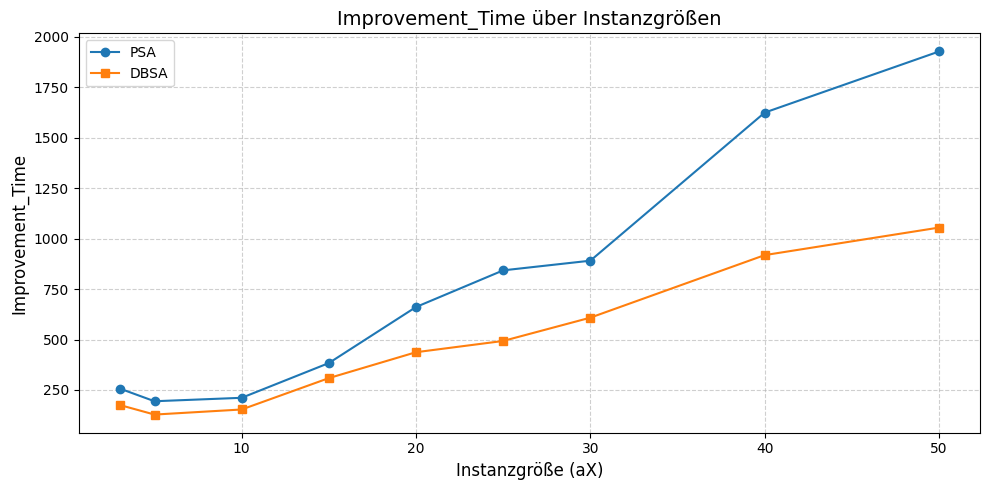

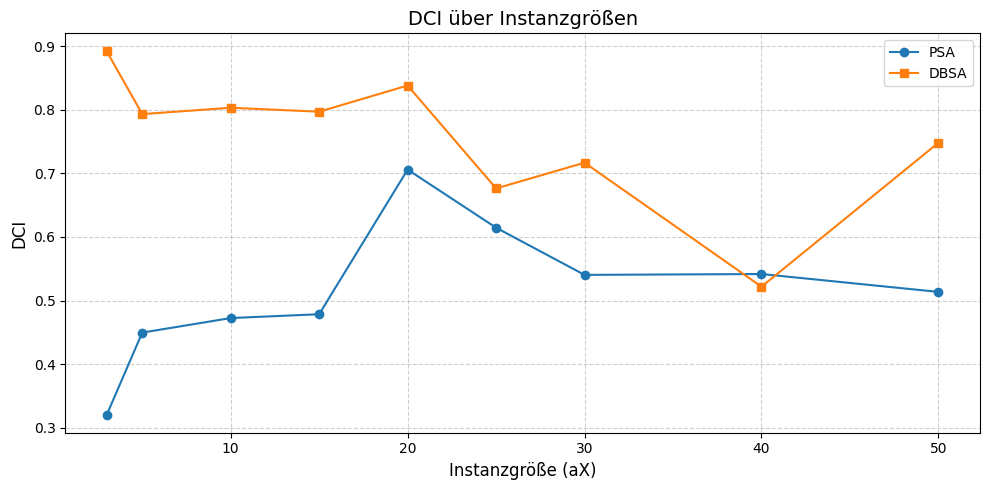

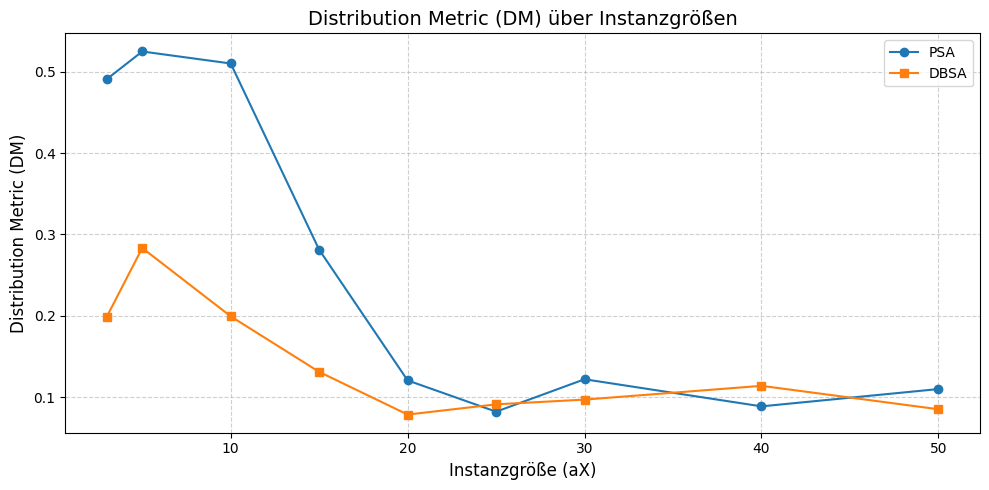

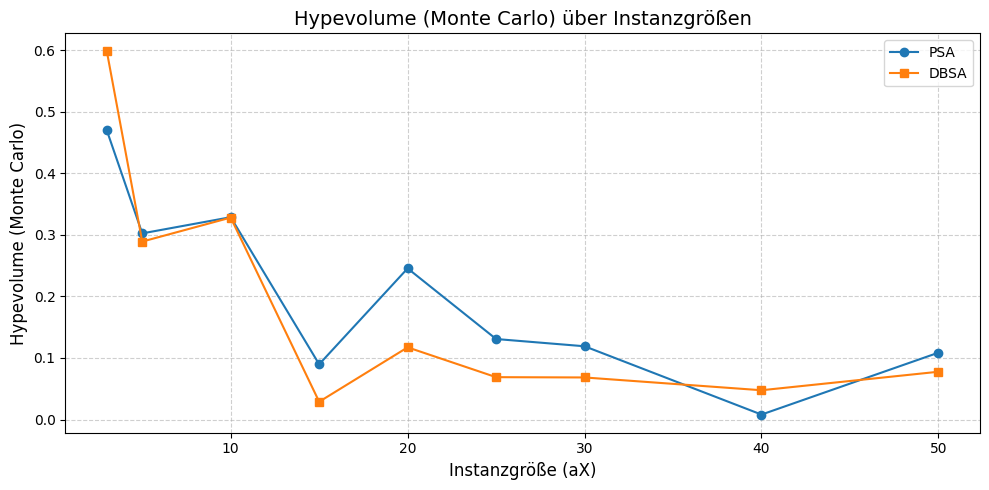

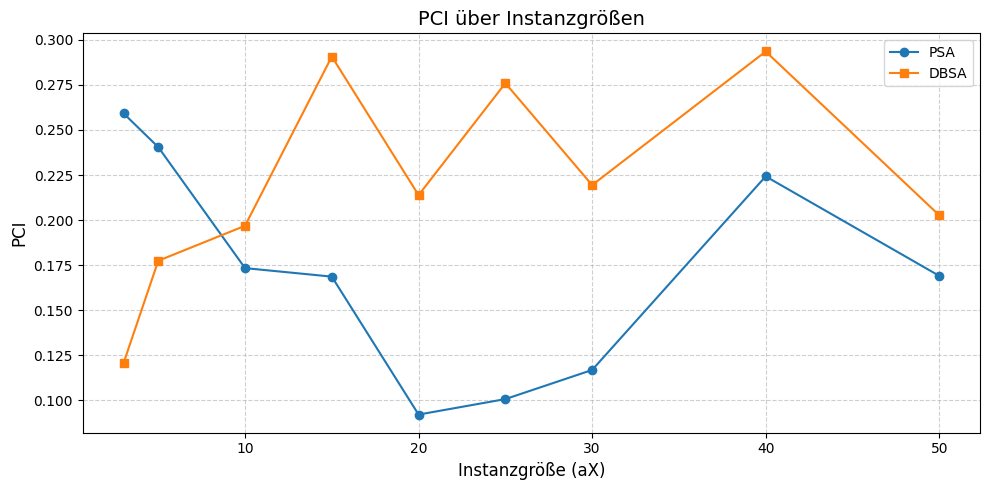

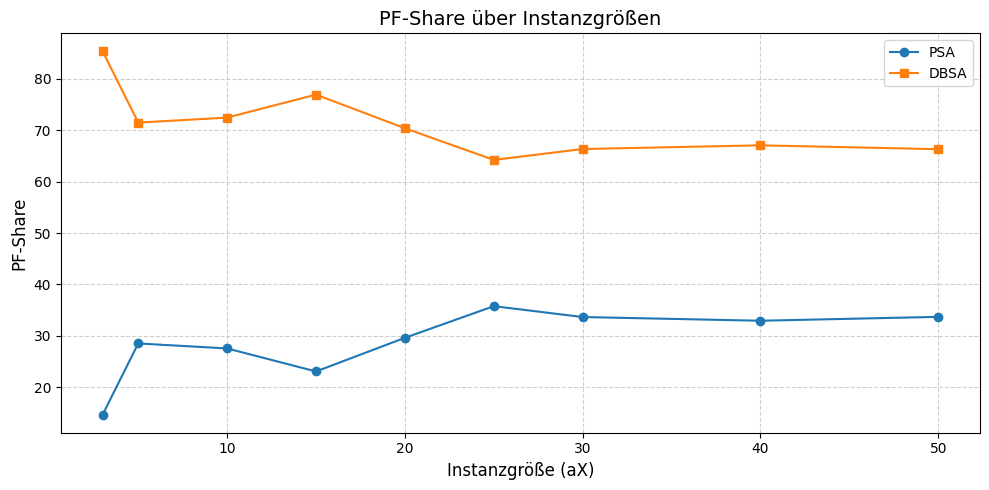

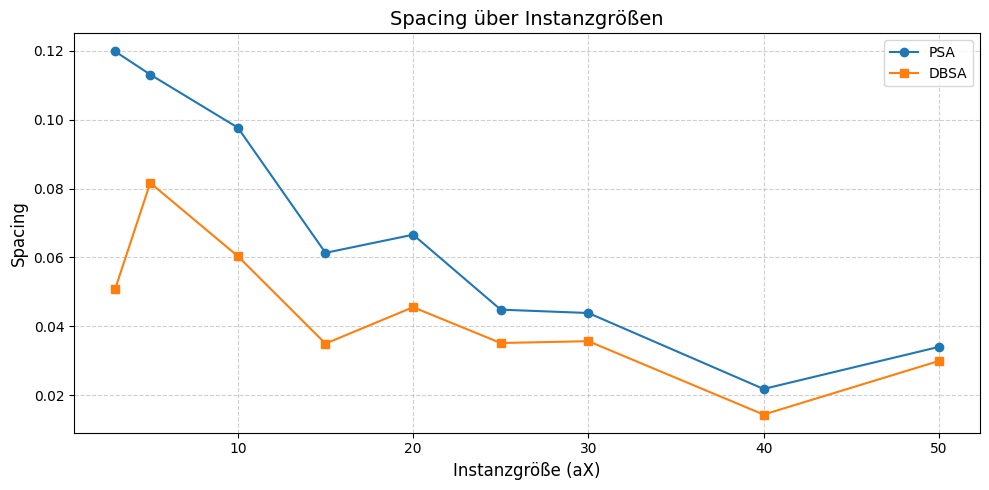

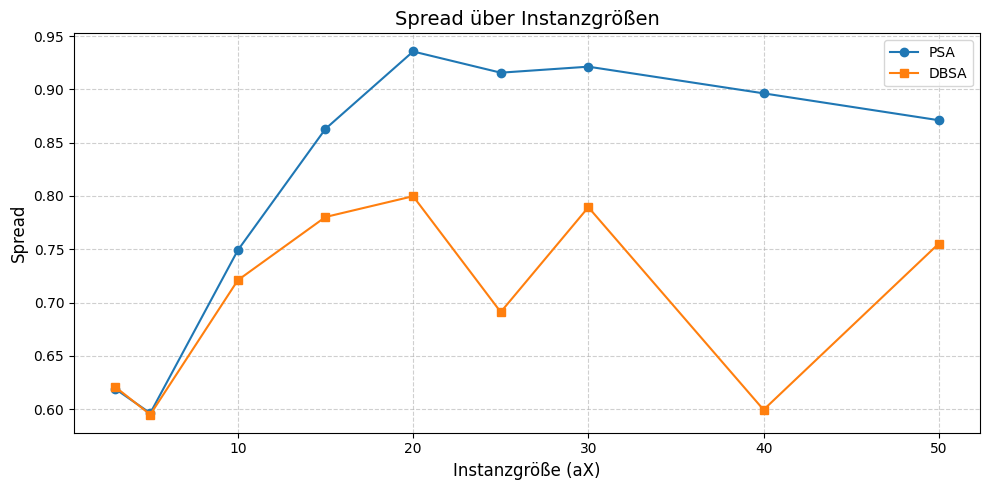

In [13]:
# 📦 Imports
import pandas as pd
import matplotlib.pyplot as plt

# 📂 Datei einlesen
file_path = "/Users/niklas/Desktop/Diplomarbeit/OptRail_Railroad_Construction/Data/Solution_PSA_DbSA/Metrics_averaged.csv"
df = pd.read_csv(file_path)

# 🔍 Instanzgröße extrahieren (z. B. 'a3_o80' → 3)
df["Instance_Size"] = df["Instance"].str.extract(r"a(\d+)_").astype(int)

# 🧹 Metriken auswählen (alle außer 'Instance', 'Algorithm', 'Instance_Size')
metrics = [col for col in df.columns if col not in ["Instance", "Algorithm", "Instance_Size"]]

# 🧮 Mittelwert pro (Instance_Size, Algorithm)
agg_df = df.groupby(["Instance_Size", "Algorithm"], as_index=False)[metrics].mean()

# 📊 Sortieren nach Instanzgröße
agg_df = agg_df.sort_values("Instance_Size")

# 🎨 Visualisierung: Jede Metrik als eigenes Diagramm
for metric in metrics:
    plt.figure(figsize=(10, 5))

    # PSA-Linie
    psa_data = agg_df[agg_df["Algorithm"] == "PSA"]
    plt.plot(psa_data["Instance_Size"], psa_data[metric], marker="o", label="PSA")

    # DBSA-Linie
    dbsa_data = agg_df[agg_df["Algorithm"] == "DBSA"]
    plt.plot(dbsa_data["Instance_Size"], dbsa_data[metric], marker="s", label="DBSA")

    # ✨ Formatierung
    plt.title(f"{metric} über Instanzgrößen", fontsize=14)
    plt.xlabel("Instanzgröße (aX)", fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [14]:
# Durchschnittswerte je Algorithmus
df.groupby("Algorithm").mean(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,394.748,0.766,0.157,0.217,0.215,71.511,0.047,0.710,19.0
PSA,635.604,0.505,0.322,0.232,0.172,28.489,0.075,0.801,19.0


In [15]:
# Standardabweichungen je Algorithmus
df.groupby("Algorithm").std(numeric_only=True).round(3)

,Improvement_Time,DCI,Distribution Metric (DM),Hypevolume (Monte Carlo),PCI,PF-Share,Spacing,Spread,Instance_Size
Algorithm,,,,,,,,,
DBSA,320.890,0.107,0.067,0.208,0.058,8.247,0.021,0.107,14.623
PSA,595.099,0.120,0.211,0.189,0.058,8.247,0.036,0.151,14.623
